I want to

In [30]:
from google.colab.patches import cv2_imshow

In [33]:
import cv2
import numpy as np

def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    _, thresh = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    return thresh



def segment_characters(thresh_img):
    contours, _ = cv2.findContours(
        thresh_img,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = [cv2.boundingRect(c) for c in contours]

    # sort left to right
    boxes = sorted(boxes, key=lambda b: b[0])

    characters = []

    for (x, y, w, h) in boxes:
        # filter out tiny noise
        if w < 8 or h < 8:
            continue

        # filter out weird shapes (optional but helpful)
        if h / w > 5 or w / h > 5:
            continue

        char_img = thresh_img[y:y+h, x:x+w]
        characters.append((char_img, (x, y, w, h)))


    debug = cv2.cvtColor(thresh_img, cv2.COLOR_GRAY2BGR)

    for (x, y, w, h) in boxes:
        cv2.rectangle(debug, (x,y), (x+w,y+h), (0,255,0), 1)

    cv2_imshow(debug)



    return characters

In [ ]:
/content/drive/MyDrive/Hackathon Case 2 Data/SimulatedNoisyOffice/simulated_noisy_images_grayscale/FontLre_Noisec_TE.png

In [65]:
image = cv2.imread("/content/drive/MyDrive/Hackathon Case 2 Data/SimulatedNoisyOffice/simulated_noisy_images_grayscale/FontLre_Noisec_TE.png")

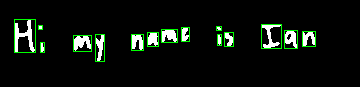

[(array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0, 255, 255, 255,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0, 255, 255, 255,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          255, 255, 255, 255,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          255, 255, 255, 255,   0,   0,   0,   0],
         [  0, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          255, 255, 255, 255,   0,   0,   0,   0],
         [  0, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          255, 255, 255, 255,   0,   0,   0,   0],
         [  0, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          255, 255, 255, 255,   0,   0,   0,   0],
         [  0, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0, 255, 255, 255,   0,   0,   0

In [36]:
segment_characters(preprocess_image(image))

In [5]:

import torch
def prepare_char(char_img):
    char_img = cv2.resize(char_img, (28, 28))
    char_img = char_img / 255.0
    char_img = torch.tensor(char_img).float()
    char_img = char_img.unsqueeze(0).unsqueeze(0)  # (1,1,28,28)
    return char_img

In [9]:
prepare_char(chars[0][0])

tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.1412, 0.2863, 0.4275, 0.5686,
           0.7137, 0.8549, 1.0000, 0.8549, 0.7137, 0.5686, 0.4275, 0.2863,
           0.1412, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.1412, 0.2863, 0.4275, 0.5725,
           0.7137, 0.8549, 1.0000, 0.8549, 0.7137, 0.5725, 0.4275, 0.2863,
           0.1412, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.1412, 0.2863, 0.4275, 0.5725,
           0.7137, 0.8588, 1.0000, 0.8588, 0.7137, 0.5725, 0.4275, 0.2863,
           0.1412, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.1412, 0.2863, 0.4275, 0.5725,
           0.7137, 0.8588, 1.0000, 0.8588, 0.7137, 0.5725, 0.4275, 0.2863,
           0.1412, 0.0000, 0.0000, 0.0000, 

In [59]:
def predict_character(model, char_img):
    model.eval()

    input_tensor = prepare_char(char_img)

    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()

    # return str(pred)
    return dic[pred]

In [11]:
def assemble_text(characters, model):
    text = ""

    prev_x = None

    for char_img, (x, y, w, h) in characters:
        if prev_x is not None:
            gap = x - prev_x

            # heuristic for space
            if gap > 15:   # tune this
                text += " "

        predicted = predict_character(model, char_img)
        text += predicted

        prev_x = x + w

    return text

In [19]:
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 47)#47 is for the number of classes

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 3 * 3)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

model = CNNModel()

In [20]:
model = CNNModel()  # Must define/import this class

# 2. Load the saved weights into it
model.load_state_dict(torch.load('/model_weights.pt'))

# 3. Set to eval mode
model.eval()

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=47, bias=True)
)

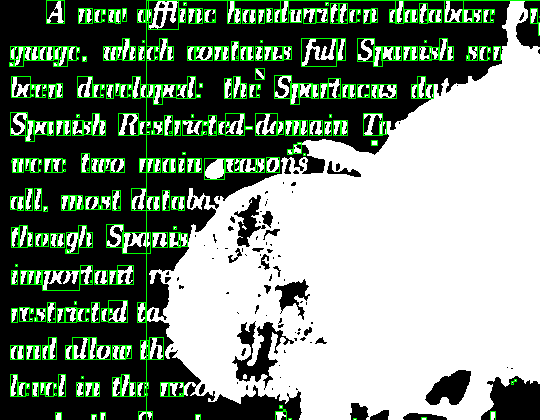

88qqqq88qqq8qqq8q88q88q8qqqq88qq8qqq8qqq8qq8qq88q8888qqq888qqq8qqqqq4q8888qqqqqq88qqqqq8888q8q8qqqq88qqq88qqqq8qq88q88


In [66]:
thresh = preprocess_image(image)
characters = segment_characters(thresh)
text = assemble_text(characters, model)
print(text)

In [64]:
char_img = cv2.imread("/Screenshot 2026-04-18 002624.png", cv2.IMREAD_GRAYSCALE)

prediction = predict_character(model, char_img)

print("Predicted digit:", prediction)

Predicted digit: 8


In [57]:
dic = {0: '0',
 1: '1',
 2: '2',
 3: '3',
 4: '4',
 5: '5',
 6: '6',
 7: '7',
 8: '8',
 9: '9',
 10: 'A',
 11: 'B',
 12: 'C',
 13: 'D',
 14: 'E',
 15: 'F',
 16: 'G',
 17: 'H',
 18: 'I',
 19: 'J',
 20: 'K',
 21: 'L',
 22: 'M',
 23: 'N',
 24: 'O',
 25: 'P',
 26: 'Q',
 27: 'R',
 28: 'S',
 29: 'T',
 30: 'U',
 31: 'V',
 32: 'W',
 33: 'X',
 34: 'Y',
 35: 'Z',
 36: 'a',
 37: 'b',
 38: 'd',
 39: 'e',
 40: 'f',
 41: 'g',
 42: 'h',
 43: 'n',
 44: 'q',
 45: 'r',
 46: 't'}